In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import torch
import torch.nn as nn
import torch.optim as optim
import nltk
nltk.download('stopwords')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kiet0\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
dataset_path = "data/Twitter_Data.csv"
df = pd.read_csv(dataset_path)
df

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0
...,...,...
162975,why these 456 crores paid neerav modi not reco...,-1.0
162976,dear rss terrorist payal gawar what about modi...,-1.0
162977,did you cover her interaction forum where she ...,0.0
162978,there big project came into india modi dream p...,0.0


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  str    
 1   category    162973 non-null  float64
dtypes: float64(1), str(1)
memory usage: 21.9 MB


In [11]:
df.describe()

,category
count,162973.000000
mean,0.225436
std,0.781279
min,-1.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [ ]:
null_rows = df.isnull().any(axis=1)
df[null_rows]

,clean_text,category
148,NaN,0.0
130448,the foundation stone northeast gas grid inaugu...,NaN
155642,dear terrorists you can run but you cant hide ...,NaN
155698,offense the best defence with mission shakti m...,NaN
155770,have always heard politicians backing out thei...,NaN
158693,modi government plans felicitate the faceless ...,NaN
158694,NaN,-1.0
159442,chidambaram gives praises modinomics,NaN
159443,NaN,0.0
160559,the reason why modi contested from seats 2014 ...,NaN


In [13]:
df = df.dropna()

In [21]:
def text_normalize(text):
    text = text.lower()

    text = re.sub(r"^rt[\s]+", "", text)
    text = re.sub(r"https?:\/\/.*[\r\n]*", "", text)

    text = re.sub(r"[^\w\s]", "", text)

    stop_words = set(stopwords.words("english"))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    text = " ".join(words)

    stemmer = SnowballStemmer("english")
    words = text.split()
    words = [stemmer.stem(word) for word in words]
    text = " ".join(words)

    return text

df ["clean_text"] = df["clean_text"].apply(lambda x: text_normalize(x))

vectorizer = TfidfVectorizer(max_features=2000)
X = vectorizer.fit_transform(df["clean_text"]).toarray()

In [38]:
n_classes = pd.unique(df['category']).shape[0]
n_samples = X.shape[0]

y = df['category'].to_numpy()
y = y.astype(np.int64)
y_encoded = np.array(
    [np.zeros(n_classes) for _ in range(n_samples)]
)
print(y_encoded ,y)
y_encoded[np.arange(n_samples), y] = 1

X = torch.tensor(X, dtype=torch.float32)
y = torch. tensor(y_encoded, dtype=torch.float32)

val_size = 0.2
test_size = 0.125
random_state = 2
is_shuffle = True

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size = val_size,
    random_state = random_state,
    shuffle = is_shuffle
)


X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train,
    test_size = test_size,
    random_state = random_state,
    shuffle = is_shuffle
)



[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 ...
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]] [-1  0  1 ...  0  0  1]


C:\Users\kiet0\AppData\Local\Temp\ipykernel_38720\4232998319.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float32)


In [49]:
class SoftmaxRegression(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(SoftmaxRegression, self).__init__()
        self.linear = nn.Linear(
            in_features = input_dim,
            out_features = output_dim,
            bias=True
        )
    def forward(self, x):
        return self.linear(x)

def compute_accuracy(y_hat, y_true):
    _, y_hat = torch.max(y_hat, dim=1)
    _, y_true = torch.max(y_true, dim=1)

    correct = torch.sum(y_hat == y_true).item()
    accuracy = correct / y_true.shape[0]

    return accuracy

In [50]:
lr = 0.1
epochs = 500
torch.manual_seed(random_state)
if torch.cuda.is_available():
    torch.cuda.manual_seed(random_state)

input_dim = X_train.shape[1]
output_dim = y_train.shape[1]

model = SoftmaxRegression(
    input_dim = input_dim,
    output_dim = output_dim
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

train_losses = []
train_accs = []
val_losses = []
val_accs = []

for epoch in range(epochs):
    model.train()

    optimizer.zero_grad(set_to_none=True)

    y_hat = model(X_train)

    train_loss = criterion(y_hat, y_train)

    train_losses.append(train_loss.item())

    train_acc = compute_accuracy(y_hat, y_train)
    train_accs.append(train_acc)

    train_loss.backward()
    optimizer.step()

    model.eval()

    with torch.no_grad():
        y_val_hat = model(X_val)

        # Compute validation loss
        val_loss = criterion(y_val_hat, y_val)
        val_losses.append(val_loss.item())

        val_acc = compute_accuracy(y_val_hat, y_val)
        val_accs.append(val_acc)

        print (f"\nEPOCH {epoch + 1}:\tTraining loss: {train_loss :.3f}\tValidation loss: {val_loss:.3f}")


EPOCH 1:	Training loss: 1.098	Validation loss: 1.019

EPOCH 2:	Training loss: 1.019	Validation loss: 0.987

EPOCH 3:	Training loss: 0.986	Validation loss: 0.952

EPOCH 4:	Training loss: 0.947	Validation loss: 0.915

EPOCH 5:	Training loss: 0.907	Validation loss: 0.884

EPOCH 6:	Training loss: 0.873	Validation loss: 0.862

EPOCH 7:	Training loss: 0.848	Validation loss: 0.847

EPOCH 8:	Training loss: 0.831	Validation loss: 0.831

EPOCH 9:	Training loss: 0.813	Validation loss: 0.812

EPOCH 10:	Training loss: 0.793	Validation loss: 0.793

EPOCH 11:	Training loss: 0.773	Validation loss: 0.778

EPOCH 12:	Training loss: 0.756	Validation loss: 0.765

EPOCH 13:	Training loss: 0.743	Validation loss: 0.754

EPOCH 14:	Training loss: 0.730	Validation loss: 0.742

EPOCH 15:	Training loss: 0.718	Validation loss: 0.729

EPOCH 16:	Training loss: 0.704	Validation loss: 0.716

EPOCH 17:	Training loss: 0.691	Validation loss: 0.704

EPOCH 18:	Training loss: 0.679	Validation loss: 0.694

EPOCH 19:	Training

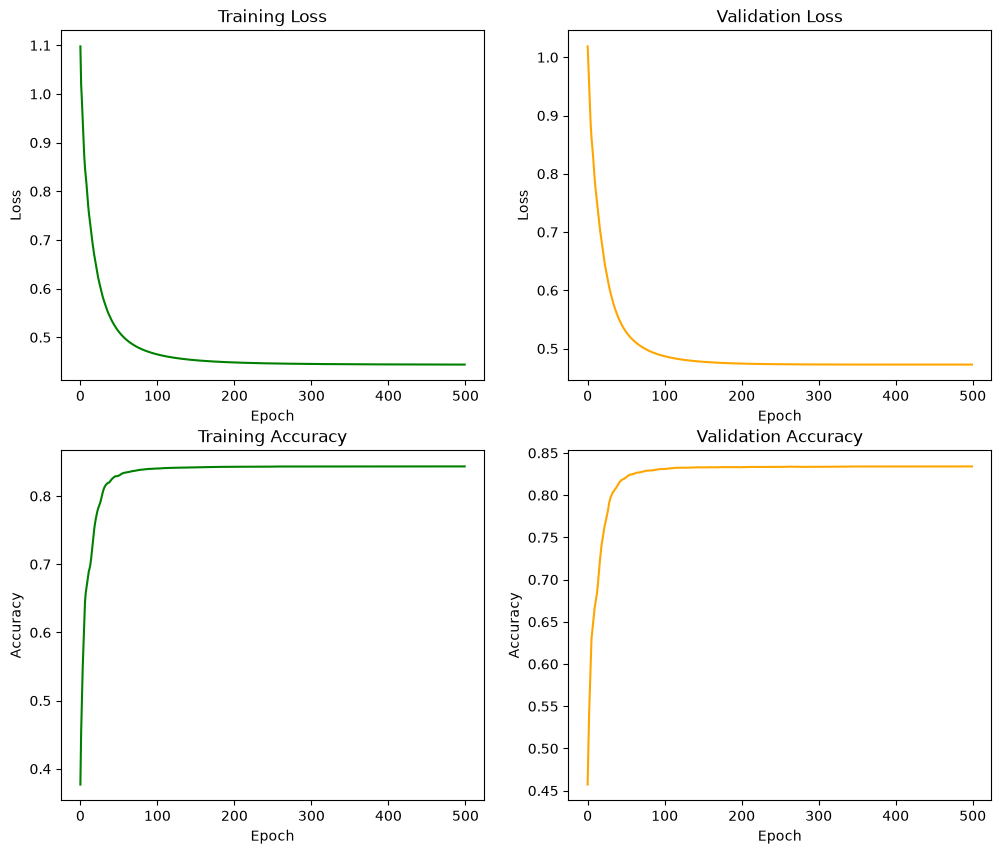

In [51]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

ax[0, 0].plot(train_losses, color="green")
ax[0, 0].set(xlabel="Epoch", ylabel="Loss")
ax[0, 0].set_title("Training Loss")

ax[0, 1].plot (val_losses, color="orange")
ax[0, 1].set(xlabel="Epoch", ylabel="Loss")
ax[0, 1].set_title("Validation Loss")

ax[1, 0].plot(train_accs, color="green")
ax[1, 0].set(xlabel="Epoch", ylabel="Accuracy")
ax[1, 0].set_title("Training Accuracy")

ax [1, 1].plot(val_accs, color="orange")
ax[1, 1].set(xlabel="Epoch", ylabel="Accuracy")
ax[1, 1].set_title("Validation Accuracy")

plt.show()